In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from numpy.random import choice
import matplotlib.pyplot as plt
from revised_greedy_up_down_functions import *

## Other Helper Functions

In [2]:
def get_root(node, tree):
    while(True):
        if(len(tree[node]["parent"])==0):
            return node
        node = tree[node]["parent"][0]

def get_initial_population(pop_size, roots, subchildren):
    population = []
    for pop in range(pop_size):
        cluster = []
        for root in roots:
            subchild = subchildren[root]
            random_num = random.randint(0, len(subchild))
            if(random_num == len(subchild)):
                cluster.append(root)
            else:
                cluster.extend(subchild[random_num])
        population.append(cluster)
    return population

def get_fitness(population, dist):
    pop_size = len(population)
    fitness_vec = []
    for pop in range(pop_size):
        a = list(population[pop])
        length = len(a)
        total_distance = 0
        for i in range(length):
            for j in range(i+1, length):
                total_distance += dist[a[i]][a[j]]
        total_pairs = length*((length-1)/2.0)
        fitness_vec.append(total_pairs/total_distance) ## inverse of avg distance
    return fitness_vec

######################################## NEW ADDITION ########################################################

def get_fitness_nearestNeighbour(population, dist):
    pop_size = len(population)
    fitness_vec = []
    for pop in range(pop_size):
        a = list(population[pop])
        length = len(a)
        total_distance = 0
        for i in range(length):
#             print("\nNEW ELEMENT")
            cur_closest_distance = 100000000
            for j in range(length):
                if(i!=j):
                    cur_distance = dist[a[i]][a[j]]
#                     print(cur_distance)
                    if(cur_distance < cur_closest_distance):
                        cur_closest_distance = cur_distance
#                         print("Closest distance updated to", cur_closest_distance)
#             print("FINAL CLOSEST DISTANCE FOR THE NEW ELEMENT", cur_closest_distance)
            total_distance += cur_closest_distance
#             print("NEW TOTAL DISTANCE", total_distance)
#         print("\nFINAL TOTAL DISTANCE", total_distance)
#         print("LENGTH", length)
#         print(length/total_distance)
        fitness_vec.append(length/total_distance) ## inverse of avg nearest neighbour distance
    return fitness_vec

def get_fitness_KnearestNeighbour(population, dist, knn):
    pop_size = len(population)
    fitness_vec = []
    for pop in range(pop_size):
        a = list(population[pop])
        length = len(a)
        if(knn > (length-1) or knn<1):
            print("Choose an appropriate K-NN value -> [1, number of roots - 1]")
            return -1
        total_distance = 0
        for i in range(length):
            cur_distance = []
            for j in range(length):
                if(i!=j):
                    cur_distance.append(dist[a[i]][a[j]])
#             print("\nNEW ELEMENT")
#             print(cur_distance)
#             print("SORTING....")
            cur_distance = np.sort(np.array(cur_distance))
#             print(cur_distance)
            cur_closest_distance = np.sum(cur_distance[:knn])/knn
#             print("AVERAGE CLOSEST DISTANCE", cur_closest_distance)
            total_distance += cur_closest_distance
#             print("TOTAL DISTANCE TILL NOW", total_distance)
#         print("LENGTH", length)
#         print(length/total_distance)
        fitness_vec.append(length/total_distance) ## inverse of avg nearest neighbour distance
    return fitness_vec

######################################## NEW ADDITION ########################################################

def mutate_cluster(x, cluster, tree, subchildren):
    for mutations in range(x): 
        node = cluster[random.randint(0, len(cluster)-1)]
        root = get_root(node, tree)
        cluster2 = []
        for clus in cluster:
            if(get_root(clus,tree) == root):
                continue
            cluster2.append(clus)
        cluster = list(cluster2)
        subchild = subchildren[root]
        random_num = random.randint(0, len(subchild))
        if(random_num == len(subchild)):
            cluster.append(root)
        else:
            cluster.extend(subchild[random_num])   
    return cluster

def get_parents(power, fitness_vec):
    sampleList = range(len(fitness_vec))
    fitness_vec_updated = [number**power for number in fitness_vec]
    fitness_vec_scaled = fitness_vec_updated/np.sum(fitness_vec_updated)
    parent_indices = choice(sampleList, p=fitness_vec_scaled, size=2, replace=False)
    return parent_indices

def crossover(parent1, parent2, roots, tree):
    cross_over_point = random.randint(1, len(roots)-1)
    child1 = []
    child2 = []
    for node in parent1:
        s = get_root(node, tree)
        if(s<cross_over_point):
            child1.append(node)
        else:
            child2.append(node)
    for node in parent2:
        s = get_root(node, tree)
        if(s<cross_over_point):
            child2.append(node)
        else:
            child1.append(node)
            
    return [child1, child2]

In [3]:
def genetic_algo(pop_size, num_generation, stop_criteria, mutations, power, knn, tree, roots, subchildren, dist, pflag):
    
    population = get_initial_population(pop_size, roots, subchildren)
    no_change = 0
    best_score = 100000000
    best_cluster = []
    cur_score_arr = []
    
    for gen in range(num_generation):
        if(pflag): print("BEST:",best_score, best_cluster)
        if(no_change >= stop_criteria):
            break
        ############################### MODIFIED ########################################
#         fitness = get_fitness(population, dist)
#         fitness = get_fitness_nearestNeighbour(population, dist)
        fitness = get_fitness_KnearestNeighbour(population, dist,knn)
        ############################### MODIFIED ########################################
        cur_score = 1/(np.max(fitness))
        cur_score_arr.append(cur_score)
        if(cur_score < best_score):
            best_cluster = population[np.argmax(fitness)]
            best_score = cur_score
            no_change = -1
        new_population = []
        for i in range(int(pop_size/2)):
            parents = get_parents(power, fitness)
            parent1 = population[parents[0]]
            parent2 = population[parents[1]]
            [child1, child2] = crossover(parent1, parent2, roots, tree)
            new_population.append(child1)
            new_population.append(child2)
        final_population = []
        for cluster in new_population:
            num_muts = random.randint(0, mutations)
            final_population.append(mutate_cluster(num_muts, cluster, tree, subchildren))
        population = list(final_population)
        no_change += 1
        
    return (best_score, best_cluster, cur_score_arr)

## Defining trees

In [4]:
tree1 = dict()

for i in range(10):
    tree1[i] = dict()
    tree1[i]["child"] = [i+34]
    tree1[i]["parent"] = []
    
tree1[10] = {"child":[44, 45], "parent":[]}

for i in range(11, 27):
    tree1[i] = dict()
    tree1[i]["child"] = [i+35]
    tree1[i]["parent"] = []

tree1[27] = {"child":[62, 63], "parent":[]}

for i in range(28, 34):
    tree1[i] = dict()
    tree1[i]["child"] = [i+36]
    tree1[i]["parent"] = []

for i in range(34, 44):
    tree1[i] = dict()
    tree1[i]["child"] = [i+36]
    tree1[i]["parent"] = [i-34]

tree1[44] = {"child":[80], "parent":[10]}
tree1[45] = {"child":[], "parent":[10]}

for i in range(46, 62):
    tree1[i] = dict()
    tree1[i]["child"] = [i+35]
    tree1[i]["parent"] = [i-35]

tree1[62] = {"child":[97], "parent":[27]}
tree1[63] = {"child":[], "parent":[27]}

tree1[64] = {"child":[98], "parent":[28]}
tree1[65] = {"child":[], "parent":[29]}

for i in range(66, 70):
    tree1[i] = dict()
    tree1[i]["child"] = [i+33]
    tree1[i]["parent"] = [i-36]
    
for i in range(70, 80):
    tree1[i] = dict()
    tree1[i]["child"] = [i+33]
    tree1[i]["parent"] = [i-36]
    
tree1[80] = {"child":[113], "parent":[44]}

for i in range(81, 97):
    tree1[i] = dict()
    tree1[i]["child"] = [i+33]
    tree1[i]["parent"] = [i-35]
    
tree1[97] = {"child":[130], "parent":[62]}
tree1[98] = {"child":[131], "parent":[64]}

for i in range(99, 103):
    tree1[i] = dict()
    tree1[i]["child"] = [i+33]
    tree1[i]["parent"] = [i-33]
    
for i in range(103, 123):
    tree1[i] = dict()
    tree1[i]["child"] = [i+33]
    tree1[i]["parent"] = [i-33]
    
tree1[123] = {"child":[], "parent":[90]}

for i in range(124, 136):
    tree1[i] = dict()
    tree1[i]["child"] = [i+32]
    tree1[i]["parent"] = [i-33]

for i in range(136, 156):
    tree1[i] = dict()
    tree1[i]["child"] = [i+32]
    tree1[i]["parent"] = [i-33]

tree1[156] = {"child":[188], "parent":[124]}
tree1[157] = {"child":[], "parent":[125]}
    
for i in range(158, 163):
    tree1[i] = dict()
    tree1[i]["child"] = [i+31]
    tree1[i]["parent"] = [i-32]
    
tree1[163] = {"child":[], "parent":[131]}
tree1[164] = {"child":[], "parent":[132]}
tree1[165] = {"child":[194], "parent":[133]}
tree1[166] = {"child":[195], "parent":[134]}
tree1[167] = {"child":[], "parent":[135]}

for i in range(168, 175):
    tree1[i] = dict()
    tree1[i]["child"] = [i+28]
    tree1[i]["parent"] = [i-32]

tree1[175] = {"child":[203, 204], "parent":[143]}

for i in range(176, 189):
    tree1[i] = dict()
    tree1[i]["child"] = [i+29]
    tree1[i]["parent"] = [i-32]
    
tree1[189] = {"child":[218], "parent":[158]}
tree1[190] = {"child":[], "parent":[159]}
tree1[191] = {"child":[219], "parent":[160]}
tree1[192] = {"child":[220], "parent":[161]}
tree1[193] = {"child":[], "parent":[162]}
tree1[194] = {"child":[], "parent":[165]}
tree1[195] = {"child":[], "parent":[166]}

for i in range(196, 203):
    tree1[i] = dict()
    tree1[i]["child"] = [i+25]
    tree1[i]["parent"] = [i-28]
    
tree1[203] = {"child":[228], "parent":[175]}
tree1[204] = {"child":[229], "parent":[175]}

for i in range(205, 213):
    tree1[i] = dict()
    tree1[i]["child"] = [i+25]
    tree1[i]["parent"] = [i-29]
    
tree1[213] = {"child":[238, 239], "parent":[184]}

for i in range(214, 218):
    tree1[i] = dict()
    tree1[i]["child"] = [i+26]
    tree1[i]["parent"] = [i-29]

tree1[218] = {"child":[], "parent":[189]}
tree1[219] = {"child":[244], "parent":[191]}
tree1[220] = {"child":[245], "parent":[192]}

for i in range(221, 238):
    tree1[i] = dict()
    tree1[i]["child"] = []
    tree1[i]["parent"] = [i-25]
    
tree1[238] = {"child":[], "parent":[213]}
tree1[239] = {"child":[], "parent":[213]}

for i in range(240, 244):
    tree1[i] = dict()
    tree1[i]["child"] = []
    tree1[i]["parent"] = [i-26]
    
tree1[244] = {"child":[], "parent":[219]}
tree1[245] = {"child":[], "parent":[220]}

    
# Verifying if the tree is correct

## Print all leaf nodes
leafs1 = []
for key in tree1:
    if(len(tree1[key]["child"])==0):
        leafs1.append(key)
print("Leaf nodes:", leafs1)

## Print all at the lowest threshold nodes
roots1 = []
for key in tree1:
    if(len(tree1[key]["parent"])==0):
        roots1.append(key)
print("Root nodes:", roots1)

## Print all paths
paths1 = []
for node in leafs1:
    node_path = [node]
    cur_node = node
    while(True):
        if(len(tree1[cur_node]["parent"])!=0):
            node_path.append(tree1[cur_node]["parent"][0])
            cur_node = tree1[cur_node]["parent"][0]
            continue
        else:
            break
    paths1.append(node_path[::-1])
print("Paths:", paths1)

Leaf nodes: [45, 63, 65, 123, 157, 163, 164, 167, 190, 193, 194, 195, 218, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245]
Root nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Paths: [[10, 45], [27, 63], [29, 65], [20, 55, 90, 123], [22, 57, 92, 125, 157], [28, 64, 98, 131, 163], [30, 66, 99, 132, 164], [33, 69, 102, 135, 167], [24, 59, 94, 127, 159, 190], [27, 62, 97, 130, 162, 193], [31, 67, 100, 133, 165, 194], [32, 68, 101, 134, 166, 195], [23, 58, 93, 126, 158, 189, 218], [0, 34, 70, 103, 136, 168, 196, 221], [1, 35, 71, 104, 137, 169, 197, 222], [2, 36, 72, 105, 138, 170, 198, 223], [3, 37, 73, 106, 139, 171, 199, 224], [4, 38, 74, 107, 140, 172, 200, 225], [5, 39, 75, 108, 141, 173, 201, 226], [6, 40, 76, 109, 142, 174, 202, 227], [7, 41, 77, 110, 143, 175, 203, 228], [7, 41, 77, 110, 143, 175, 204, 229], [8, 42, 78, 1

In [5]:
tree2 = dict()

for i in range(10):
    tree2[i] = dict()
    tree2[i]['child'] = [i+26]
    tree2[i]['parent'] = []

tree2[10] = {'child': [36, 37], 'parent': []}
tree2[11] = {'child': [38, 39], 'parent': []}

for i in range(12,26):
    tree2[i] = dict()
    tree2[i]['child'] = [i+28]
    tree2[i]['parent'] = []

for i in range(26, 36):
    tree2[i] = dict()
    tree2[i]['child'] = [i+28]
    tree2[i]['parent'] = [i-26]

tree2[36] = {'child': [64], 'parent': [10]}
tree2[37] = {'child': [65], 'parent': [10]}
tree2[38] = {'child': [66], 'parent': [11]}
tree2[39] = {'child': [67], 'parent': [11]}

for i in range(40, 43):
    tree2[i] = dict()
    tree2[i]['child'] = [i+28]
    tree2[i]['parent'] = [i-28]

tree2[43] = {'child': [], 'parent': [15]}

for i in range(44, 54):
    tree2[i] = dict()
    tree2[i]['child'] = [i+27]
    tree2[i]['parent'] = [i-28]

for i in range(54, 64):
    tree2[i] = dict()
    tree2[i]['child'] = [i+27]
    tree2[i]['parent'] = [i-28]

tree2[64] = {'child': [91], 'parent': [36]}
tree2[65] = {'child': [], 'parent': [37]}
tree2[66] = {'child': [92], 'parent': [38]}
tree2[67] = {'child': [], 'parent': [39]}

for i in range(68, 71):
    tree2[i] = dict()
    tree2[i]['child'] = [i+25]
    tree2[i]['parent'] = [i-28]

for i in range(71, 81):
    tree2[i] = dict()
    tree2[i]['child'] = [i+25]
    tree2[i]['parent'] = [i-27]

for i in range(81, 91):
    tree2[i] = dict()
    tree2[i]['child'] = [i+25]
    tree2[i]['parent'] = [i-27]

tree2[91] = {'child': [116], 'parent': [64]}
tree2[92] = {'child': [117, 118], 'parent': [66]}

for i in range(93, 104):
    tree2[i] = dict()
    tree2[i]['child'] = [i+26]
    tree2[i]['parent'] = [i-25]

tree2[104] = {'child': [], 'parent': [79]}
tree2[105] = {'child': [130], 'parent': [80]}

for i in range(106, 117):
    tree2[i] = dict()
    tree2[i]['child'] = [i+25]
    tree2[i]['parent'] = [i-25]

tree2[117] = {'child': [142], 'parent': [92]}
tree2[118] = {'child': [143], 'parent': [92]}

for i in range(119, 128):
    tree2[i] = dict()
    tree2[i]['child'] = [i+25]
    tree2[i]['parent'] = [i-26]

tree2[128] = {'child': [], 'parent': [102]}
tree2[129] = {'child': [153], 'parent': [103]}
tree2[130] = {'child': [154], 'parent': [105]}

for i in range(131, 152):
    tree2[i] = dict()
    tree2[i]['child'] = [i+24]
    tree2[i]['parent'] = [i-25]

tree2[152] = {'child': [], 'parent': [127]}
tree2[153] = {'child': [176], 'parent': [129]}
tree2[154] = {'child': [177], 'parent': [130]}

tree2[155] = {'child': [178], 'parent': [131]}
tree2[156] = {'child': [179], 'parent': [132]}
tree2[157] = {'child': [], 'parent': [133]}

tree2[158] = {'child': [180], 'parent': [134]}
tree2[159] = {'child': [181], 'parent': [135]}
tree2[160] = {'child': [], 'parent': [136]}

for i in range(161, 176):
    tree2[i] = dict()
    tree2[i]['child'] = [i+21]
    tree2[i]['parent'] = [i-24]

tree2[176] = {'child': [197], 'parent': [153]}
tree2[177] = {'child': [], 'parent': [154]}

tree2[178] = {'child': [], 'parent': [155]}
tree2[179] = {'child': [], 'parent': [156]}
tree2[180] = {'child': [], 'parent': [158]}
tree2[181] = {'child': [], 'parent': [159]}

for i in range(182, 198):
    tree2[i] = dict()
    tree2[i]['child'] = []
    tree2[i]['parent'] = [i-21]
    
# Verifying if the tree is correct

## Print all leaf nodes
leafs2 = []
for key in tree2:
    if(len(tree2[key]["child"])==0):
        leafs2.append(key)
print("Leaf nodes:", leafs2)

## Print all at the lowest threshold nodes
roots2 = []
for key in tree2:
    if(len(tree2[key]["parent"])==0):
        roots2.append(key)
print("Root nodes:", roots2)

## Print all paths
paths2 = []
for node in leafs2:
    node_path = [node]
    cur_node = node
    while(True):
        if(len(tree2[cur_node]["parent"])!=0):
            node_path.append(tree2[cur_node]["parent"][0])
            cur_node = tree2[cur_node]["parent"][0]
            continue
        else:
            break
    paths2.append(node_path[::-1])
print("Paths:", paths2)

Leaf nodes: [43, 65, 67, 104, 128, 152, 157, 160, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197]
Root nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Paths: [[15, 43], [10, 37, 65], [11, 39, 67], [24, 52, 79, 104], [22, 50, 77, 102, 128], [21, 49, 76, 101, 127, 152], [2, 28, 56, 83, 108, 133, 157], [5, 31, 59, 86, 111, 136, 160], [25, 53, 80, 105, 130, 154, 177], [0, 26, 54, 81, 106, 131, 155, 178], [1, 27, 55, 82, 107, 132, 156, 179], [3, 29, 57, 84, 109, 134, 158, 180], [4, 30, 58, 85, 110, 135, 159, 181], [6, 32, 60, 87, 112, 137, 161, 182], [7, 33, 61, 88, 113, 138, 162, 183], [8, 34, 62, 89, 114, 139, 163, 184], [9, 35, 63, 90, 115, 140, 164, 185], [10, 36, 64, 91, 116, 141, 165, 186], [11, 38, 66, 92, 117, 142, 166, 187], [11, 38, 66, 92, 118, 143, 167, 188], [12, 40, 68, 93, 119, 144, 168, 189], [13, 41, 69, 94, 120, 145, 169, 190], [14, 42, 70, 95, 121, 146, 170, 191]

## P7

In [6]:
shapes_dist_euc1 = np.load("p7_ShapeDist_6144_Euc.npy")
shapes_dist_euc1.shape

(246, 246)

In [7]:
subchildren1 = get_complete_children_sets(tree1)

### Answers by nc2 and knn are very different

In [61]:
print(1/(get_fitness_nearestNeighbour(np.expand_dims(np.array([169, 196, 225, 228, 204, 174, 226, 171, 231, 205, 198, 113, 45, 235, 180, 179, 155, 154, 212, 236, 217, 92, 129, 191, 159, 158, 123, 97, 63, 131, 65, 134, 100, 167, 238, 239, 132, 185]),axis=0), shapes_dist_euc1)[0]))

48.15741447770034


In [62]:
print(1/(get_fitness(np.expand_dims(np.array([123, 164, 194, 65, 163, 188, 125, 218, 244, 159, 68, 167, 193, 63, 245, 145, 186, 148, 49, 48, 52, 233, 183, 171, 140, 201, 203, 204, 205, 109, 238, 239, 155, 196, 137, 170, 207, 45]),axis=0), shapes_dist_euc1)[0]))

256.1580691862197


### Trying different powers

54.88060283660889
36.97234041460466 [186, 156, 125, 58, 155, 123, 129, 191, 62, 63, 159, 170, 196, 225, 171, 240, 152, 85, 201, 205, 109, 203, 204, 145, 146, 45, 46, 148, 14, 137, 13, 164, 163, 167, 68, 194, 65]


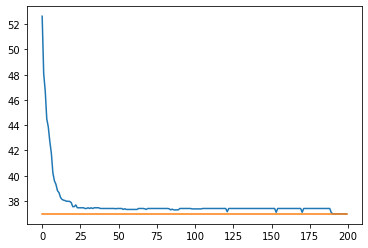

In [44]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 100
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

57.39965033531189
36.24014857465273 [68, 167, 164, 65, 163, 245, 193, 63, 191, 194, 196, 137, 170, 171, 201, 172, 203, 204, 109, 205, 145, 178, 45, 116, 148, 186, 52, 238, 239, 150, 147, 237, 155, 123, 218, 159, 125, 188]


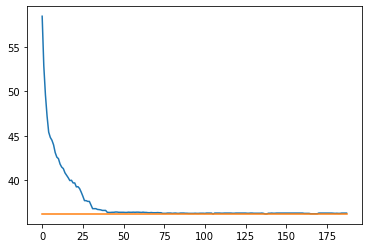

In [45]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 50
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

58.572686195373535
36.88972304054814 [164, 68, 167, 194, 158, 145, 205, 233, 48, 82, 183, 49, 238, 239, 52, 186, 125, 123, 155, 188, 191, 159, 65, 163, 245, 193, 63, 207, 45, 137, 196, 223, 201, 171, 172, 203, 229, 40]


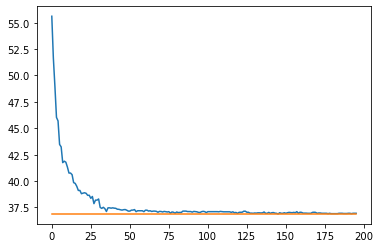

In [46]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 25
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

38.48795747756958
36.65190519863082 [123, 164, 194, 65, 163, 188, 125, 218, 244, 159, 68, 167, 193, 63, 245, 145, 186, 148, 49, 48, 52, 233, 183, 171, 140, 201, 203, 204, 205, 109, 238, 239, 155, 196, 137, 170, 207, 45]


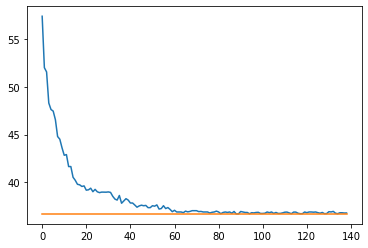

In [47]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

43.81439828872681
36.76840829217074 [167, 159, 245, 163, 194, 164, 191, 155, 123, 218, 188, 125, 65, 68, 162, 63, 200, 171, 201, 109, 145, 205, 178, 45, 203, 204, 84, 212, 233, 83, 148, 52, 238, 239, 136, 170, 137, 186]


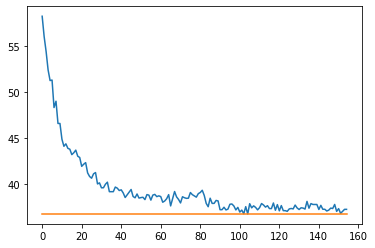

In [49]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 10
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

34.144213914871216
52.070092689083666 [137, 136, 85, 114, 145, 174, 203, 229, 83, 240, 47, 141, 133, 135, 195, 243, 59, 62, 63, 58, 163, 65, 132, 245, 154, 89, 160, 92, 205, 119, 150, 73, 198, 207, 45, 74, 55]


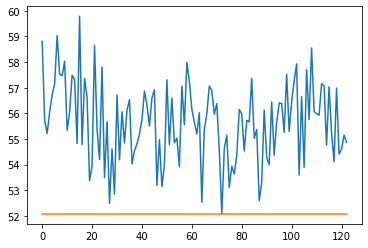

In [50]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 1
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

### Trying k nearest neighbours

85.58162045478821
51.877655816362214 [156, 123, 238, 239, 185, 154, 155, 196, 223, 197, 212, 116, 150, 205, 233, 115, 146, 45, 142, 201, 199, 225, 231, 228, 229, 163, 191, 245, 65, 158, 190, 92, 164, 167, 134, 165, 193, 63]


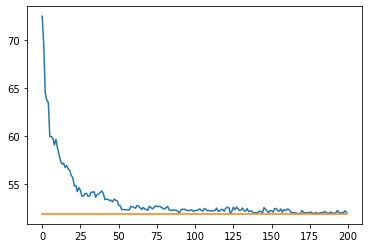

In [55]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 3
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

83.853107213974
60.60649115971083 [245, 193, 63, 134, 167, 163, 165, 164, 65, 223, 171, 169, 225, 196, 173, 174, 228, 204, 185, 212, 238, 239, 182, 116, 180, 208, 145, 205, 146, 45, 154, 155, 188, 125, 158, 159, 123, 191]


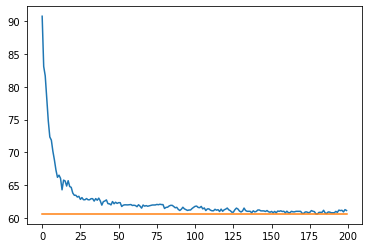

In [54]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 5
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

84.19334602355957
68.89879332152674 [196, 171, 169, 198, 225, 188, 158, 123, 155, 154, 125, 174, 205, 203, 204, 226, 145, 149, 180, 208, 146, 45, 212, 238, 239, 182, 185, 163, 245, 65, 191, 159, 167, 164, 165, 134, 193, 63]


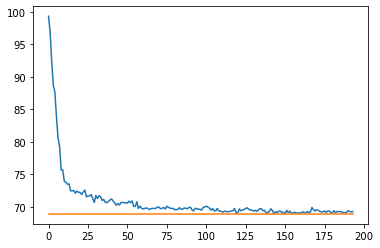

In [56]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 7
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree1, roots1, subchildren1, shapes_dist_euc1, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

## P46

In [11]:
shapes_dist_euc2 = np.load("p46_ShapeDist_6144_Euc.npy")
shapes_dist_euc2.shape

(198, 198)

In [12]:
subchildren2 = get_complete_children_sets(tree2)

### Answers by nc2 and knn are very different

In [58]:
print(1/(get_fitness_nearestNeighbour(np.expand_dims(np.array([101, 50, 158, 132, 133, 138, 137, 136, 159, 115, 163, 141, 65, 142, 167, 39, 126, 121, 43, 123, 149, 150, 147, 145, 168, 155, 80, 176, 52]),axis=0), shapes_dist_euc2)[0]))

74.95230245582775


In [60]:
print(1/(get_fitness(np.expand_dims(np.array([162, 139, 185, 137, 116, 65, 189, 92, 67, 73, 125, 105, 78, 48, 152, 22, 79, 42, 71, 97, 43, 41, 55, 133, 180, 58, 160, 106]),axis=0), shapes_dist_euc2)[0]))

376.97797319641336


### Trying different k values

62.39836645126343
52.062228778436186 [97, 73, 42, 71, 41, 189, 92, 67, 116, 65, 137, 185, 139, 43, 152, 48, 125, 78, 79, 22, 105, 162, 160, 58, 180, 133, 55, 106]


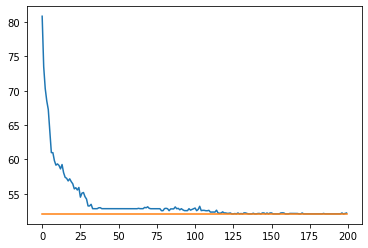

In [13]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 1
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree2, roots2, subchildren2, shapes_dist_euc2, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

69.08755254745483
76.70951441943777 [74, 92, 67, 185, 73, 123, 43, 41, 71, 121, 189, 141, 65, 152, 48, 77, 79, 105, 78, 155, 107, 133, 158, 139, 162, 159, 161, 86]


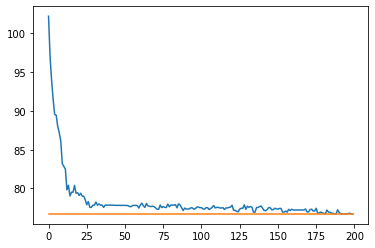

In [14]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 3
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree2, roots2, subchildren2, shapes_dist_euc2, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

45.85446047782898
92.96997269774653 [97, 149, 101, 50, 74, 147, 43, 176, 105, 79, 189, 191, 69, 140, 141, 65, 142, 167, 67, 139, 137, 138, 31, 159, 158, 131, 179, 133, 100]


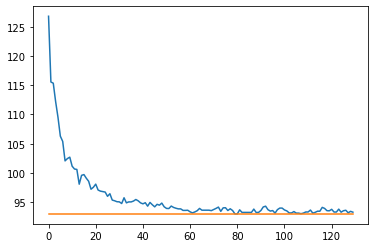

In [15]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 5
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree2, roots2, subchildren2, shapes_dist_euc2, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

61.8586847782135
104.66908636346488 [176, 79, 77, 101, 100, 105, 131, 132, 158, 138, 137, 31, 159, 133, 139, 115, 141, 65, 142, 167, 39, 149, 74, 97, 147, 43, 191, 189, 145]


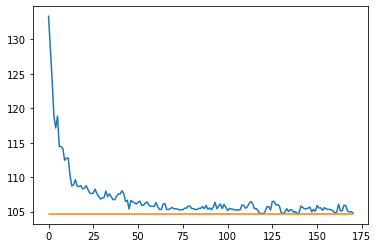

In [16]:
pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 7
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree2, roots2, subchildren2, shapes_dist_euc2, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)